In [42]:
print("internship task 02📝")

internship task 02📝


In [36]:
print("Advanced Data Cleaning & EDA using titanic sample data set")

Advanced Data Cleaning & EDA using titanic sample data set


In [37]:
print("step1:importing necessary libraries")

step1:importing necessary libraries


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [40]:
print("-------load sample titanic dataset------")

-------load sample titanic dataset------


In [43]:

df = pd.read_excel("titanic_dataset.xlsx")
df.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.25,S
1,2,1,1,female,38.0,1,0,71.28,C
2,3,1,3,female,26.0,0,0,7.92,S
3,4,1,1,female,35.0,1,0,53.10,S
4,5,0,3,male,35.0,0,0,8.05,S


In [44]:
print("2️⃣ Advanced Data Cleaning Operations")

2️⃣ Advanced Data Cleaning Operations


In [45]:
print("🔹 2.1 Check Duplicate Rows")

🔹 2.1 Check Duplicate Rows


In [46]:
df.duplicated().sum()


np.int64(0)

In [47]:
print("🔹 2.2 Handle Missing Values (Safe Method)")

🔹 2.2 Handle Missing Values (Safe Method)


In [49]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [50]:
print("🔹 2.3 Detect Outliers (IQR Method)")

🔹 2.3 Detect Outliers (IQR Method)


In [51]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
outliers


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked


In [52]:
df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]


In [55]:
print("🔹 3.1 Create Family Size Feature")

🔹 3.1 Create Family Size Feature


In [56]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df[['SibSp', 'Parch', 'FamilySize']].head()


,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [57]:
print("🔹 3.2 Create Age Group Feature")

🔹 3.2 Create Age Group Feature


In [58]:
bins = [0, 12, 20, 40, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df[['Age', 'AgeGroup']].head()


,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


from matplotlib import pyplot as plt
_df_0['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Age'].plot(kind='line', figsize=(8, 4), title='Age')
plt.gca().spines[['top', 'right']].set_visible(False)

In [59]:
print("4️⃣ Encoding Categorical Variables")

4️⃣ Encoding Categorical Variables


In [62]:
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'FamilySize', 'Embarked_Q', 'Embarked_S', 'AgeGroup_Teen',
       'AgeGroup_Adult', 'AgeGroup_MiddleAge', 'AgeGroup_Senior'],
      dtype='object')

In [64]:
bins = [0, 12, 20, 40, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)


In [65]:
df[['Age', 'AgeGroup']].head()


,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


from matplotlib import pyplot as plt
_df_2['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Age'].plot(kind='line', figsize=(8, 4), title='Age')
plt.gca().spines[['top', 'right']].set_visible(False)

In [66]:
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'FamilySize', 'Embarked_Q', 'Embarked_S', 'AgeGroup_Teen',
       'AgeGroup_Adult', 'AgeGroup_MiddleAge', 'AgeGroup_Senior', 'AgeGroup'],
      dtype='object')

In [68]:
df = pd.get_dummies(df, columns=['AgeGroup'], drop_first=True)


In [70]:
cols_to_encode = []

if 'Embarked' in df.columns:
    cols_to_encode.append('Embarked')

if 'AgeGroup' in df.columns:
    cols_to_encode.append('AgeGroup')

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)


In [71]:
print("5️⃣ Advanced EDA Operations")

5️⃣ Advanced EDA Operations


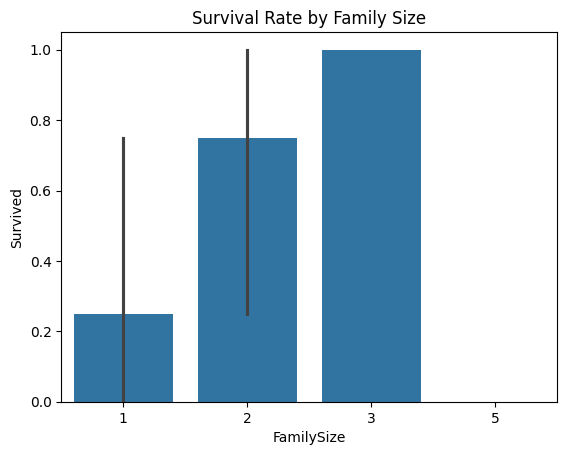

In [72]:
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title("Survival Rate by Family Size")
plt.show()


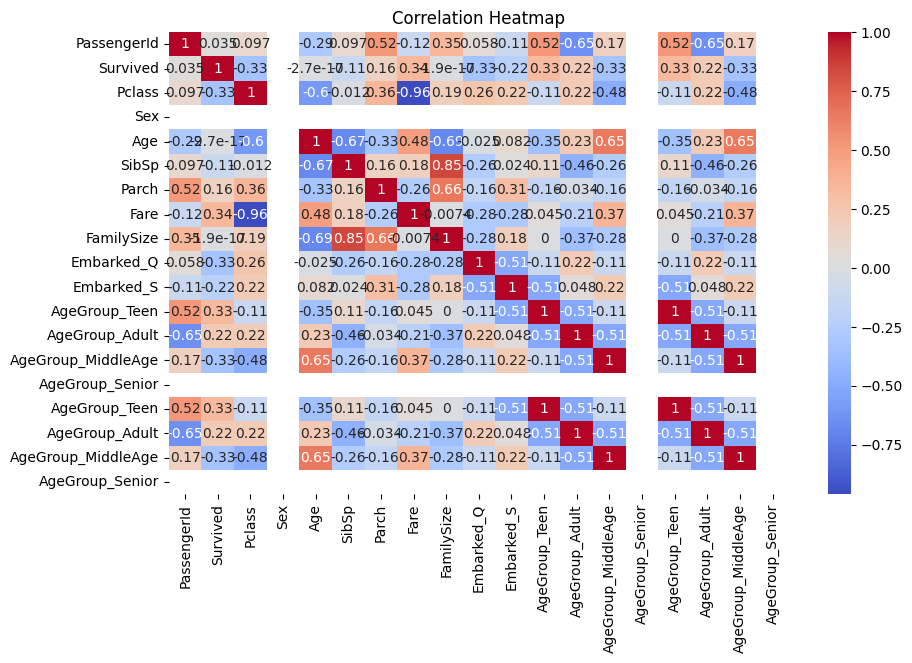

In [74]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


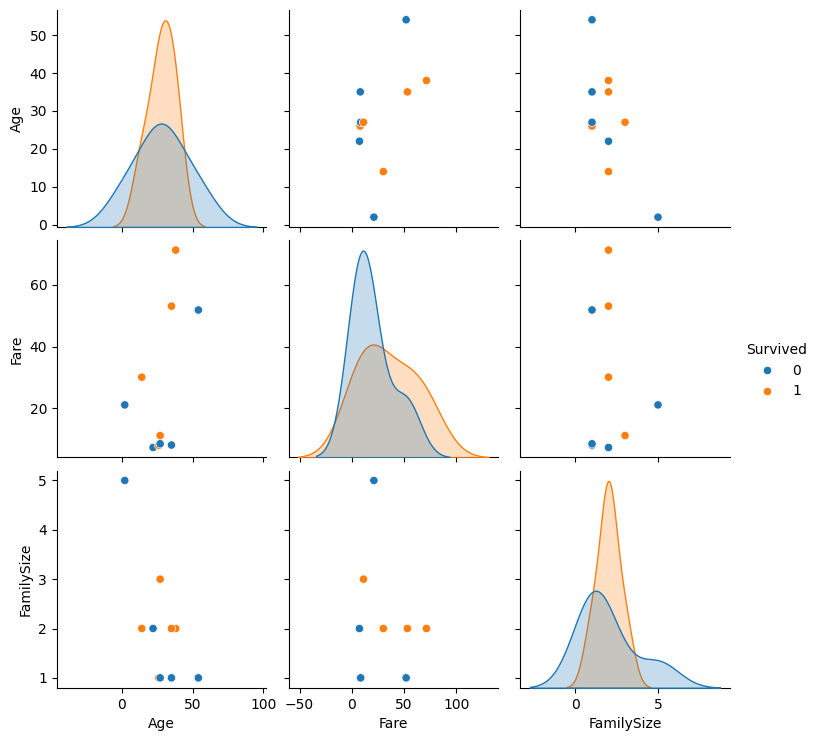

In [75]:
sns.pairplot(df[['Survived', 'Age', 'Fare', 'FamilySize']], hue='Survived')
plt.show()


In [76]:
print("6️⃣ Aggregations & GroupBy (INTERVIEW GOLD ⭐)")

6️⃣ Aggregations & GroupBy (INTERVIEW GOLD ⭐)


In [77]:
print("🔹 Survival by Class")

🔹 Survival by Class


In [78]:
df.groupby('Pclass')['Survived'].mean()


,Survived
Pclass,
1,0.666667
2,1.000000
3,0.333333


In [79]:
print("🔹 Survival by Gender")

🔹 Survival by Gender


In [80]:
df.groupby('Sex')['Survived'].mean()


,Survived
Sex,


In [81]:
print("🔹 Survival by Embarked")

🔹 Survival by Embarked


In [82]:
df.groupby('Embarked_S')['Survived'].mean()


,Survived
Embarked_S,
False,0.666667
True,0.428571


In [85]:
print("7️⃣ Statistical Operations(Mean, Median, Std)")

7️⃣ Statistical Operations(Mean, Median, Std)


In [86]:
df[['Age', 'Fare']].agg(['mean', 'median', 'std'])


,Age,Fare
mean,28.000000,27.019000
median,27.000000,16.100000
std,14.094916,23.601634


from matplotlib import pyplot as plt
_df_4['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_5['Fare'].plot(kind='hist', bins=20, title='Fare')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_6.plot(kind='scatter', x='Age', y='Fare', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7['Age'].plot(kind='line', figsize=(8, 4), title='Age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_8['Fare'].plot(kind='line', figsize=(8, 4), title='Fare')
plt.gca().spines[['top', 'right']].set_visible(False)

In [87]:
print("🔹 Survival Rate (%)")

🔹 Survival Rate (%)


In [88]:
survival_rate = df['Survived'].value_counts(normalize=True) * 100
survival_rate


,proportion
Survived,
0,50.0
1,50.0


In [89]:
print("8️⃣ Save Cleaned Dataset")

8️⃣ Save Cleaned Dataset


In [91]:
from google.colab import drive
drive.mount('/content/drive')


df.to_excel("/content/drive/MyDrive/cleaned_titanic_dataset.xlsx", index=False)


Mounted at /content/drive
